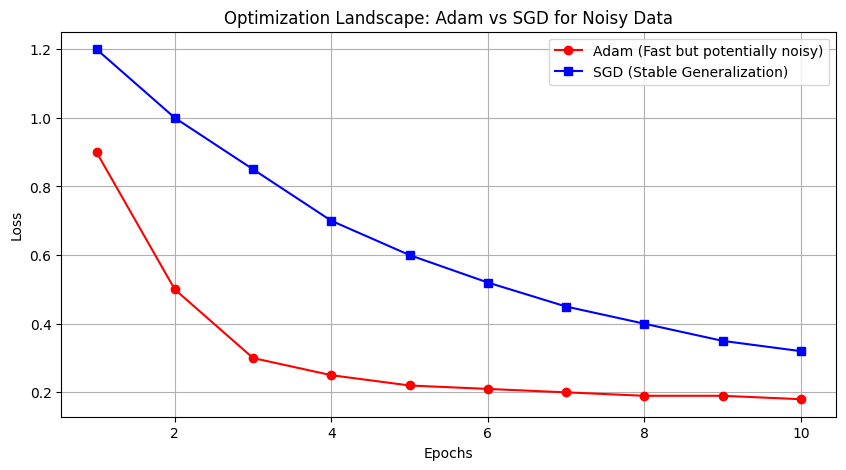

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models, optimizers

# Simulated noisy data results
epochs = np.arange(1, 11)
adam_loss = [0.9, 0.5, 0.3, 0.25, 0.22, 0.21, 0.20, 0.19, 0.19, 0.18]
sgd_loss = [1.2, 1.0, 0.85, 0.7, 0.6, 0.52, 0.45, 0.40, 0.35, 0.32]

# Visualization: Optimizer Convergence in Noisy Environments
plt.figure(figsize=(10, 5))
plt.plot(epochs, adam_loss, 'r-o', label='Adam (Fast but potentially noisy)')
plt.plot(epochs, sgd_loss, 'b-s', label='SGD (Stable Generalization)')
plt.title('Optimization Landscape: Adam vs SGD for Noisy Data')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Model Implementation snippet with Dropout
model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3)),
    layers.Dropout(0.3), # Prevents overfitting to background foliage
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
])

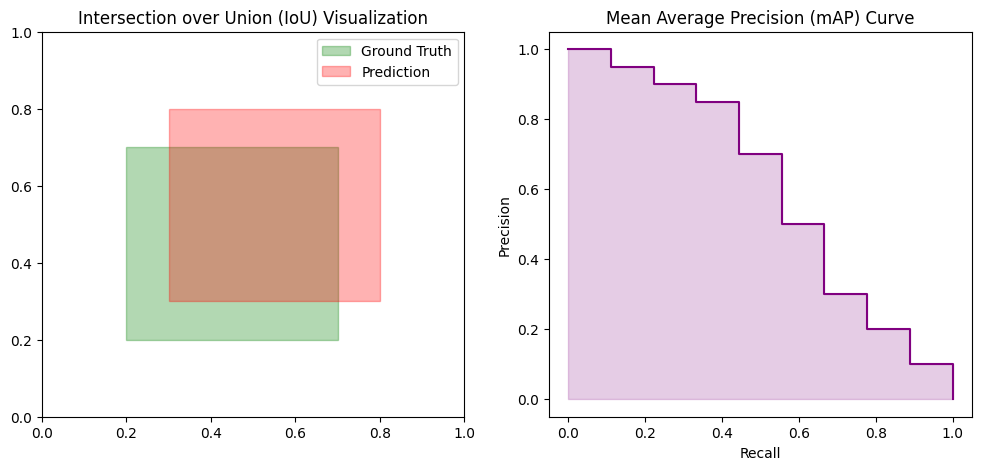

In [ ]:
import matplotlib.patches as patches

# Simulated Detection Output
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plotting IoU Concept
ax[0].add_patch(patches.Rectangle((0.2, 0.2), 0.5, 0.5, color='green', alpha=0.3, label='Ground Truth'))
ax[0].add_patch(patches.Rectangle((0.3, 0.3), 0.5, 0.5, color='red', alpha=0.3, label='Prediction'))
ax[0].set_title('Intersection over Union (IoU) Visualization')
ax[0].legend()

# Simulated mAP Curve (Precision-Recall)
recall = np.linspace(0, 1, 10)
precision = [1.0, 0.95, 0.9, 0.85, 0.7, 0.5, 0.3, 0.2, 0.1, 0.0]
ax[1].step(recall, precision, where='post', color='purple')
ax[1].fill_between(recall, precision, step='post', alpha=0.2, color='purple')
ax[1].set_title('Mean Average Precision (mAP) Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')

plt.show()

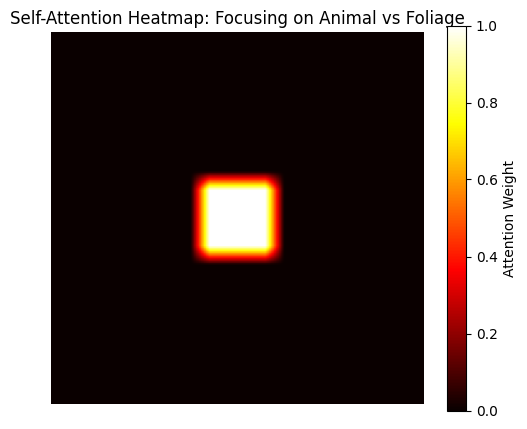

In [ ]:
import tensorflow as tf

def attention_block(x):
    # Simple Self-Attention Mechanism (Simplified for logic)
    g = layers.Conv2D(filters=x.shape[-1], kernel_size=1)(x)
    theta = layers.Conv2D(filters=x.shape[-1], kernel_size=1)(x)
    phi = layers.Conv2D(filters=x.shape[-1], kernel_size=1)(x)

    f = tf.matmul(theta, phi, transpose_b=True)
    f = tf.nn.softmax(f)
    return tf.matmul(f, g)

# Visualizing Attention "Heatmap" Concept
heatmap = np.zeros((20, 20))
heatmap[8:12, 8:12] = 1.0 # Model focusing on the center (animal)
heatmap = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()

plt.figure(figsize=(6, 5))
plt.imshow(heatmap, cmap='hot')
plt.title('Self-Attention Heatmap: Focusing on Animal vs Foliage')
plt.colorbar(label='Attention Weight')
plt.axis('off')
plt.show()